In [ ]:
from tensorflow.keras import Sequential, layers
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D,Conv2D, MaxPooling2D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from pathlib import Path

In [ ]:
# === Parameters ===
IMG_WIDTH, IMG_HEIGHT = 224, 224
BATCH_SIZE = 32
NUM_TRAINABLE_LAYERS = 0 # Change this to >0 when you want to fine-tune

BASE_DIR = Path.cwd()
# === Directories ===
TRAIN_DATA_DIR = BASE_DIR / "Fish_Dataset_Splitted" / "train"
VALIDATION_DATA_DIR = BASE_DIR / "Fish_Dataset_Splitted" / "validation"
TEST_DATA_DIR = BASE_DIR / "Fish_Dataset_Splitted" / "test"

In [6]:
# === Data Generators ===
train_datagen = ImageDataGenerator(
rotation_range=20,
width_shift_range=0.2,
height_shift_range=0.2,
zoom_range=0.2,
horizontal_flip=True)

val_test_datagen = ImageDataGenerator()

train_generator = train_datagen.flow_from_directory(
TRAIN_DATA_DIR,
target_size=(IMG_WIDTH, IMG_HEIGHT),
batch_size=BATCH_SIZE,
class_mode="sparse",
shuffle=True
)

validation_generator = val_test_datagen.flow_from_directory(
VALIDATION_DATA_DIR,
target_size=(IMG_WIDTH, IMG_HEIGHT),
batch_size=BATCH_SIZE,
class_mode="sparse",
shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
TEST_DATA_DIR,
target_size=(IMG_WIDTH, IMG_HEIGHT),
batch_size=BATCH_SIZE,
class_mode="sparse",
shuffle=False)


Found 4000 images belonging to 5 classes.
Found 500 images belonging to 5 classes.
Found 500 images belonging to 5 classes.


In [12]:
model = Sequential([
    layers.Rescaling(1./255, input_shape=(224,224,3)),

    Conv2D(32, 3, padding="same", activation="relu"),
    MaxPooling2D(),

    Conv2D(64, 3, padding="same", activation="relu"),
    MaxPooling2D(),

    Conv2D(128, 3, padding="same", activation="relu"),
    MaxPooling2D(),

    Conv2D(256, 3, padding="same", activation="relu"),

    GlobalAveragePooling2D(),

    Dense(128, activation="relu"),
    Dropout(0.4),

    Dense(5, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


#EarlyStopping
es = EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=5,
    restore_best_weights=True
)
# === Train ===
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=50,
    callbacks=[es]
)

Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 124s 977ms/step - accuracy: 0.3490 - loss: 1.4452 - val_accuracy: 0.5020 - val_loss: 1.1103
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 120s 957ms/step - accuracy: 0.6472 - loss: 0.8743 - val_accuracy: 0.7880 - val_loss: 0.6080
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 106s 849ms/step - accuracy: 0.7575 - loss: 0.6129 - val_accuracy: 0.8420 - val_loss: 0.4449
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 120s 956ms/step - accuracy: 0.7872 - loss: 0.5451 - val_accuracy: 0.8780 - val_loss: 0.3749
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 118s 942ms/step - accuracy: 0.8127 - loss: 0.4707 - val_accuracy: 0.8980 - val_loss: 0.3179
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 110s 879ms/step - accuracy: 0.8428 - loss: 0.4045 - val_accuracy: 0.8380 - val_loss: 0.3502
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 117s 929ms/step - accuracy: 0.8710 - loss: 0.3402 - val_accuracy: 0.9020 - val_loss: 0.2629
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 100s 796ms/step - accuracy: 0.8857 -

In [13]:
model.save("modelo_peces_Custom.keras")
print("¡Modelo guardado con éxito en el disco!")

¡Modelo guardado con éxito en el disco!


¡Modelo cargado desde el disco con éxito!
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 281ms/step - accuracy: 0.9980 - loss: 0.0159
Test Accuracy (del modelo cargado): 0.9980


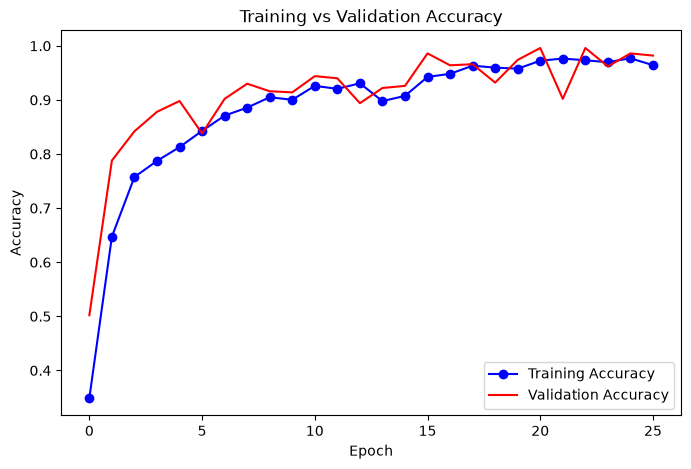

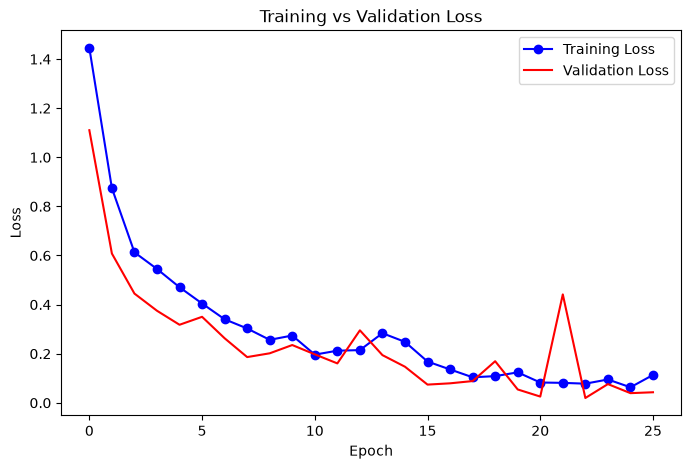

In [14]:
ruta_guardado = r"C:\IA-FAC\modelo_peces_Custom.keras"

# 2. Cargamos exactamente el archivo que acabamos de guardar
modelo_cargado = load_model(ruta_guardado)
print("¡Modelo cargado desde el disco con éxito!")
# === Evaluar sin pisar el historial ===
# Cambiamos los nombres a 'test_loss' y 'test_acc' para proteger las listas del historial
test_loss, test_acc = modelo_cargado.evaluate(test_generator)
print(f"Test Accuracy (del modelo cargado): {test_acc:.4f}")

# === Extraer historiales originales ===
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(len(accuracy))

# === Gráfica 1: Accuracy ===
plt.figure(figsize=(8,5))
plt.plot(epochs, accuracy, "bo-", label="Training Accuracy")
plt.plot(epochs, val_accuracy, "r-", label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# === Gráfica 2: Loss ===
plt.figure(figsize=(8,5))
plt.plot(epochs, loss, "bo-", label="Training Loss")
plt.plot(epochs, val_loss, "r-", label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()